# 01 EDA: DeepSolar Dataset Exploration

Understand data structure, target distribution, missing values, and prefix groups.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import load_data, get_prefix, get_us_only_cols, get_target_cols

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

## Load Data

In [2]:
df = load_data('../deepsolar_tract.csv')
print('Shape:', df.shape)

Shape: (72537, 169)


## Target Variable: tile_count

In [3]:
target = 'tile_count'
print(df[target].describe())
print(f"\nZero count: {(df[target] == 0).sum()} ({(df[target] == 0).mean()*100:.1f}%)")
print(f"Non-zero median: {df.loc[df[target] > 0, target].median():.1f}")

count    72537.000000
mean        30.255787
std         86.337406
min          0.000000
25%          1.000000
50%          4.000000
75%         22.000000
max       4468.000000
Name: tile_count, dtype: float64

Zero count: 16279 (22.4%)
Non-zero median: 8.0


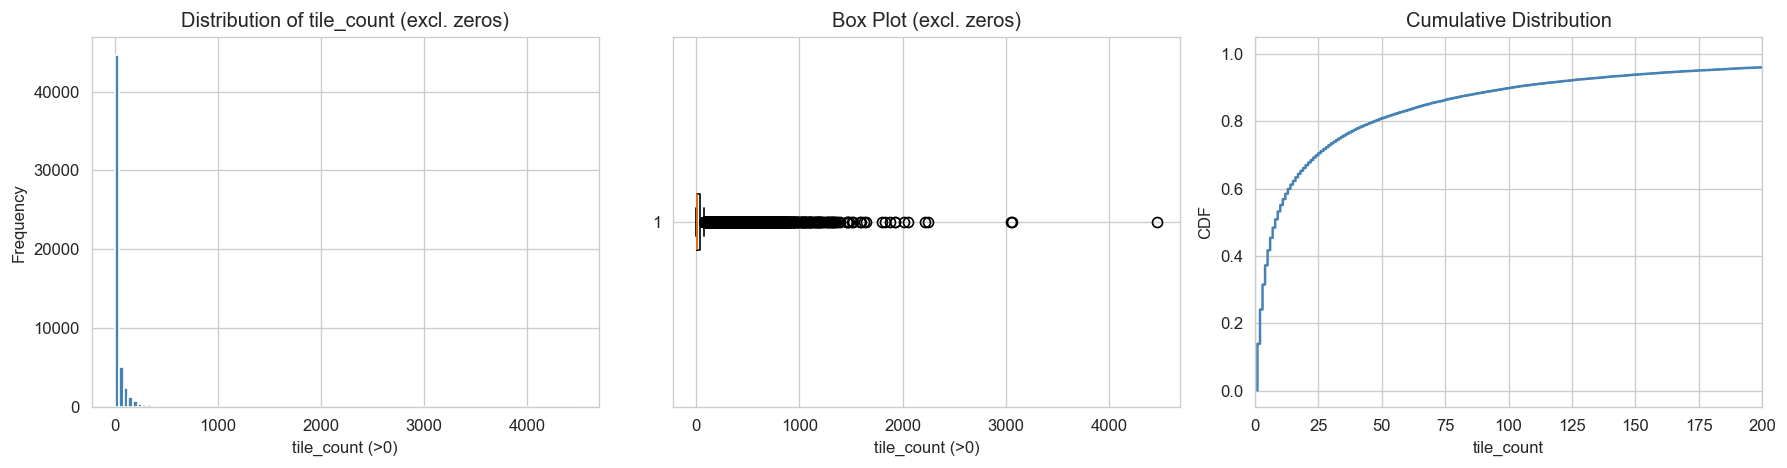

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram (log scale)
axes[0].hist(df[target][df[target] > 0], bins=100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('tile_count (>0)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of tile_count (excl. zeros)')

# Box plot
axes[1].boxplot(df[target][df[target] > 0], vert=False)
axes[1].set_xlabel('tile_count (>0)')
axes[1].set_title('Box Plot (excl. zeros)')

# CDF
sorted_vals = np.sort(df[target][df[target] > 0])
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[2].plot(sorted_vals, cdf, color='steelblue')
axes[2].set_xlabel('tile_count')
axes[2].set_ylabel('CDF')
axes[2].set_title('Cumulative Distribution')
axes[2].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('../outputs/figures/01_tile_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Prefix Grouping

In [6]:
from collections import Counter

prefixes = Counter(get_prefix(c) for c in df.columns)
prefix_df = pd.DataFrame(prefixes.most_common(), columns=['prefix', 'count'])
print(prefix_df.head(20))

            prefix  count
0          heating     17
1        education     15
2             race     14
3           single     12
4              age     12
5       occupation     12
6      electricity      9
7   transportation      7
8           travel      7
9           voting      6
10           solar      5
11           total      4
12         housing      4
13       incentive      4
14            tile      3
15         poverty      3
16         average      2
17       household      2
18         cooling      2
19           earth      2


In [7]:
# Show columns by prefix for key groups
key_prefixes = ['solar', 'electricity', 'heating', 'cooling', 'education', 'population', 'housing', 'incentive', 'race', 'voting']
for p in key_prefixes:
    cols = [c for c in df.columns if get_prefix(c) == p]
    print(f"\n{p} ({len(cols)}): {cols}")


solar (5): ['solar_system_count', 'solar_panel_area_divided_by_area', 'solar_panel_area_per_capita', 'solar_system_count_residential', 'solar_system_count_nonresidential']

electricity (9): ['electricity_price_residential', 'electricity_price_commercial', 'electricity_price_industrial', 'electricity_price_transportation', 'electricity_price_overall', 'electricity_consume_residential', 'electricity_consume_commercial', 'electricity_consume_industrial', 'electricity_consume_total']

heating (17): ['heating_fuel_coal_coke', 'heating_fuel_electricity', 'heating_fuel_fuel_oil_kerosene', 'heating_fuel_gas', 'heating_fuel_housing_unit_count', 'heating_fuel_none', 'heating_fuel_other', 'heating_fuel_solar', 'heating_fuel_gas_rate', 'heating_fuel_electricity_rate', 'heating_fuel_fuel_oil_kerosene_rate', 'heating_fuel_coal_coke_rate', 'heating_fuel_solar_rate', 'heating_fuel_other_rate', 'heating_fuel_none_rate', 'heating_design_temperature', 'heating_degree_days']

cooling (2): ['cooling_desig

## Missing Values

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)} / {len(df.columns)}")
print(missing.head(20))

Columns with missing values: 103 / 169
voting_2012_dem_percentage        10554
voting_2012_gop_percentage        10554
elevation                          5802
lon                                5802
cooling_design_temperature         5802
lat                                5802
relative_humidity                  5802
earth_temperature_amplitude        5802
earth_temperature                  5802
heating_design_temperature         5802
frost_days                         5802
heating_degree_days                5802
cooling_degree_days                5802
wind_speed                         5802
atmospheric_pressure               5802
daily_solar_radiation              5802
air_temperature                    5802
housing_unit_median_gross_rent     1976
housing_unit_median_value          1894
mortgage_with_rate                 1136
dtype: int64


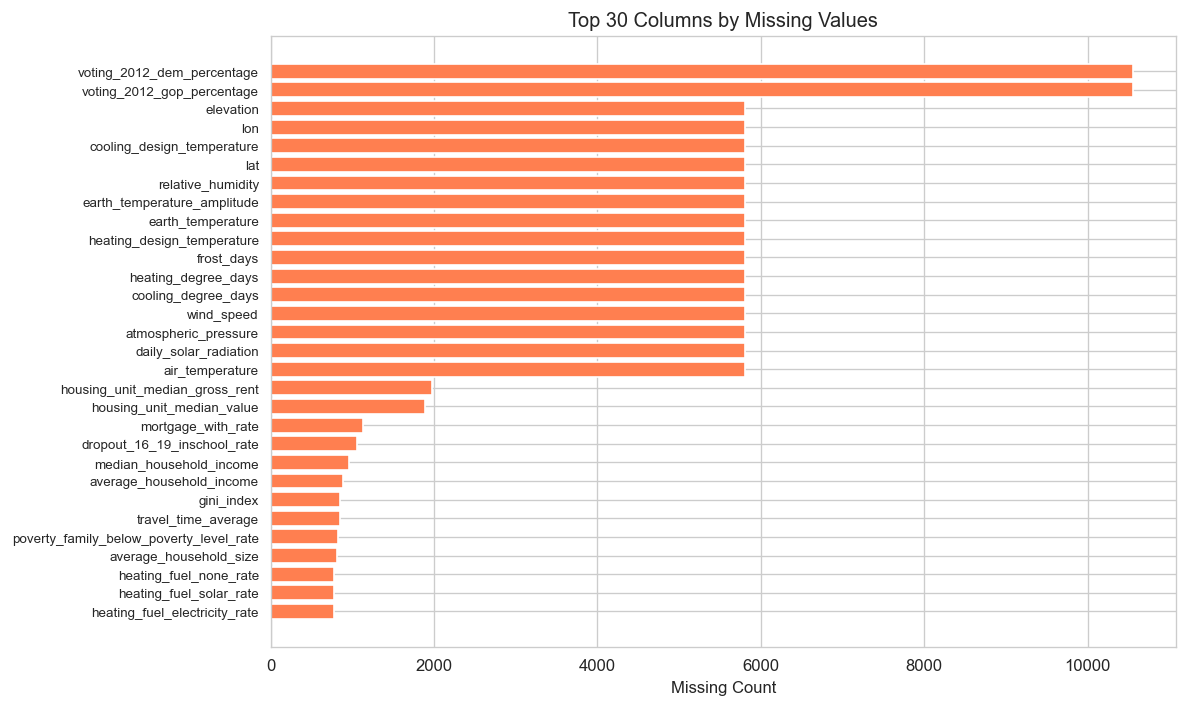

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_top = missing.head(30)
ax.barh(range(len(missing_top)), missing_top.values, color='coral')
ax.set_yticks(range(len(missing_top)))
ax.set_yticklabels(missing_top.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Missing Count')
ax.set_title('Top 30 Columns by Missing Values')
plt.tight_layout()
plt.savefig('../outputs/figures/01_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

## US-only vs Generalizable Features

In [10]:
us_only = get_us_only_cols()
targets = get_target_cols()
us_only_exist = [c for c in us_only if c in df.columns]
targets_exist = [c for c in targets if c in df.columns]

print(f"US-only columns found: {len(us_only_exist)}")
print(f"Target columns found: {len(targets_exist)}")

generalizable = [c for c in df.columns if c not in us_only_exist + targets_exist]
print(f"Generalizable feature columns: {len(generalizable)}")
print(f"Total: {len(df.columns)}")

US-only columns found: 34
Target columns found: 12
Generalizable feature columns: 123
Total: 169


## Correlation with Target (Preview)

In [11]:
# Numeric columns only for preview
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()[target].drop(target).sort_values(key=abs, ascending=False)
print('Top 15 positively correlated:')
print(corr_with_target.head(15))
print('\nTop 15 negatively correlated:')
print(corr_with_target.tail(15))

Top 15 positively correlated:
solar_system_count                      0.899767
total_panel_area_residential            0.860234
tile_count_residential                  0.859787
solar_system_count_residential          0.857702
solar_system_count_nonresidential       0.836872
total_panel_area                        0.787353
tile_count_nonresidential               0.738657
total_panel_area_nonresidential         0.643371
number_of_solar_system_per_household    0.511970
solar_panel_area_divided_by_area        0.487082
incentive_count_residential             0.361331
incentive_count_nonresidential          0.358120
relative_humidity                      -0.356200
electricity_price_industrial            0.336128
daily_solar_radiation                   0.327462
Name: tile_count, dtype: float64

Top 15 negatively correlated:
heating_fuel_fuel_oil_kerosene_rate   -0.016867
water_area                            -0.016485
poverty_family_below_poverty_level    -0.015407
race_indian_alaska_rate    

## Save Processed Metadata

In [12]:
# Save column metadata for downstream notebooks
meta = {
    'us_only_cols': us_only_exist,
    'target_cols': targets_exist,
    'generalizable_cols': generalizable,
    'missing_cols': missing.index.tolist(),
    'prefix_counts': dict(prefixes),
}
import json
with open('../data/processed/column_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved to data/processed/column_metadata.json')

Saved to data/processed/column_metadata.json
